In [17]:
import sys
sys.path.insert(0, '/code/src')

import pandas as pd 
import numpy as np
from datetime import datetime, date
import seaborn as sns
import pynwb
from matplotlib import pyplot as plt
import time
from tqdm.auto import tqdm

import importlib
import module
importlib.reload(module)
from module import decode_trial_identity

from sklearn.svm import LinearSVC
from sklearn import svm
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import confusion_matrix

In [18]:
from aind_data_access_api.document_db import MetadataDbClient

API_GATEWAY_HOST = "api.allenneuraldynamics.org"
DATABASE = 'metadata_index'
COLLECTION = 'data_assets'

docdb_api_client = MetadataDbClient(
   host=API_GATEWAY_HOST,
    version="v2",
   database=DATABASE,
   collection=COLLECTION,
)
print(docdb_api_client._base_url)

https://api.allenneuraldynamics.org/v2/metadata_index/data_assets


In [19]:
aggregate = [
  {
    "$match": {
      "data_description.project_name": "Dynamic Routing", 
      "data_description.data_level": "derived", 
      "processing.data_processes": {
        "$elemMatch": {
          "process_type": "File format conversion",
          "start_date_time": {"$regex": "^2026-08-04"}
        }
      }
    }
  },
  {
    "$project": {
      "name": 1, 
      "subject_id": "$data_description.subject_id",
      "genotype": "$subject.subject_details.genotype", 
      "date_of_birth": "$subject.subject_details.date_of_birth", 
      "sex": "$subject.subject_details.sex",  
      "session_start_time": "$acquisition.acquisition_start_time",
      "session_end_time": "$acquisition.acquisition_end_time", 
      "stimulus_epochs": "$acquisition.stimulus_epochs",
      "project_name": "$data_description.project_name", 
      "modality": "$data_description.modalities.name", 
      "targeted_structure": "$acquisition.data_streams.configurations.probes.primary_targeted_structure.name" 
    }
  },
]
    
records = docdb_api_client.aggregate_docdb_records(pipeline=aggregate)

# Extract performance metrics in Python
for r in records:
    dr = next((e for e in r.get("stimulus_epochs", []) if e.get("stimulus_name") == "DynamicRouting1"), None)
    r["dr_performance"] = dr["performance_metrics"] if dr else None

In [20]:
df = pd.DataFrame(records)
df['session_date'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).date(), axis=1)
df['session_start_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_start_time']).time(), axis=1)
df['session_end_time'] = df.apply(lambda x: datetime.fromisoformat(x['session_end_time']).time(), axis=1)
df['date_of_birth'] = df.apply(lambda x: datetime.strptime(x['date_of_birth'], '%Y-%m-%d').date(), axis=1)
df['age'] = df.apply(lambda x: (x['session_date'] - x['date_of_birth']).days, axis=1)

df['trials_total'] = df['dr_performance'].apply(lambda x: x['trials_total'] if x else None)
df['trials_rewarded'] = df['dr_performance'].apply(lambda x: x['trials_rewarded'] if x else None)
df['reward_rate'] = df['trials_rewarded'] / df['trials_total']
df['reward_consumed_mL'] = df['dr_performance'].apply(lambda x: x['reward_consumed_during_epoch'] if x else None)
df['block_metrics'] = df['dr_performance'].apply(lambda x: x['output_parameters']['block_metrics'] if x else None)
df['mean_dprime_same_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_same_modal'] for b in x.values()]).mean() if x else None
)
df['mean_dprime_other_modal'] = df['block_metrics'].apply(
    lambda x: pd.Series([b['dprime_other_modal_go'] for b in x.values()]).mean() if x else None
)

order = ['project_name', '_id', 'name', 'subject_id', 'genotype', 'date_of_birth', 'age', 'sex',
         'modality', 'session_date', 'session_start_time', 'session_end_time', 'targeted_structure',
         'trials_total', 'trials_rewarded', 'reward_rate', 'reward_consumed_mL',
         'mean_dprime_same_modal', 'mean_dprime_other_modal']
df = df[order].sort_values(by='subject_id')

In [21]:
# --- Pass 1: scan every mouse x region for the decoding criterion ----------
# Four decoders, each run within a single task block:
#
#   error decoder  -> block TARGET-stimulus HIT  vs  block DISTRACTOR FALSE ALARM
#                     aud block: sound1 hit  vs  vis1  false alarm
#                     vis block: vis1  hit  vs  sound1 false alarm
#                     (stimulus identity is confounded with the lick / error
#                      signal -- that is the point of the comparison below)
#
#   stim  decoder  -> sound2 vs vis2 on CORRECT-REJECT trials (licking correctly
#                     withheld), so it reads stimulus identity only and is not
#                     confounded by the lick / error signal
#
# Both decoders are run separately in the auditory block and in the visual
# block, giving four decoders total: error_aud, error_vis, stim_aud, stim_vis.
#
# A region-session qualifies for a decoder if it has >= MIN_UNITS QC units and
# >= MIN_TRIALS_PER_CLASS trials in each of that decoder's two classes.
#
# The datacube is a read-only FUSE mount, so an individual chunk read can fail
# with OSError (Errno 5) even though the path exists. Each session load is
# retried; a session whose data stays unreadable is skipped and recorded in
# `failed_sessions` instead of aborting the whole scan.

from module import get_stim_times, _BLOCK_STIM

MIN_UNITS = 50
MIN_TRIALS_PER_CLASS = 10
MIN_SESSIONS = 3          # keep regions meeting criterion in >= 3 sessions

N_LOAD_RETRIES = 1        # attempts per session before giving up on it
LOAD_RETRY_WAIT = 10      # seconds between attempts

# name -> (stim_a, outcome_a, stim_b, outcome_b, block)
DECODER_TRIALS = {
    'error_aud': ('sound1', 'is_hit',            'vis1',   'is_false_alarm',    'aud'),
    'error_vis': ('vis1',   'is_hit',            'sound1', 'is_false_alarm',    'vis'),
    'stim_aud':  ('sound2', 'is_correct_reject', 'vis2',   'is_correct_reject', 'aud'),
    'stim_vis':  ('sound2', 'is_correct_reject', 'vis2',   'is_correct_reject', 'vis'),
}


def load_session(nwb_path, n_retries=N_LOAD_RETRIES, wait=LOAD_RETRY_WAIT):
    """Read one session, retrying failed reads from the datacube mount.

    Returns (nwbfile, units_df, trials_df), or None if every attempt failed.
    Both tables are materialised here so that a chunk the mount cannot serve
    fails now, on a session we can skip, rather than later inside Pass 2.
    """
    for attempt in range(1, n_retries + 1):
        try:
            nwbfile = pynwb.read_nwb(nwb_path)
            return nwbfile, nwbfile.units.to_dataframe(), nwbfile.trials.to_dataframe()
        except OSError as err:
            tqdm.write(f"  read failed (attempt {attempt}/{n_retries}): {err}")
            if attempt < n_retries:
                time.sleep(wait)
    return None


nwb_cache = {}            # subject_id -> (nwbfile, units_df, trials_df), reused in Pass 2
failed_sessions = []      # sessions the mount would not serve
scan_rows = []
for _, m in tqdm(list(df.iterrows()), desc="scan", unit="mouse"):
    nwb_path = f"/data/dynamicrouting_datacube/{m['name']}/{m['name'][8:25]}.nwb.zarr"
    t0 = time.time()
    loaded = load_session(nwb_path)
    if loaded is None:
        failed_sessions.append(dict(mouse_id=m['subject_id'], name=m['name']))
        tqdm.write(f"{m['subject_id']}: SKIPPED -- unreadable after "
                   f"{N_LOAD_RETRIES} attempts ({time.time() - t0:.0f}s)")
        continue
    nwbfile, units, trials = loaded
    nwb_cache[m['subject_id']] = (nwbfile, units, trials)

    # trials per class for each decoder (block match is on by default)
    trial_counts = {}
    for name, (sa, oa, sb, ob, blk) in DECODER_TRIALS.items():
        na = int(get_stim_times(trials, sa, blk, oa).sum())
        nb = int(get_stim_times(trials, sb, blk, ob).sum())
        trial_counts[name] = (na, nb)

    unit_counts = units.loc[units.default_qc, 'structure'].value_counts()
    for region, n_units in unit_counts.items():
        units_ok = n_units >= MIN_UNITS
        row = dict(mouse_id=m['subject_id'], region=region, n_units=int(n_units))
        for name, (na, nb) in trial_counts.items():
            row[f'n_{name}_a'] = na
            row[f'n_{name}_b'] = nb
            row[f'meets_{name}'] = bool(units_ok
                                       and na >= MIN_TRIALS_PER_CLASS
                                       and nb >= MIN_TRIALS_PER_CLASS)
        scan_rows.append(row)
    tqdm.write(f"{m['subject_id']}: "
               + " | ".join(f"{k} {v[0]}/{v[1]}" for k, v in trial_counts.items())
               + f"  ({time.time() - t0:.0f}s to load)")

scan = pd.DataFrame(scan_rows)

if failed_sessions:
    print(f"\n!! {len(failed_sessions)} of {len(df)} sessions skipped as unreadable: "
          + ", ".join(f['mouse_id'] for f in failed_sessions))
print(f"scanned {scan.mouse_id.nunique()} sessions, "
      f"{scan.region.nunique()} distinct regions\n")

def _keep(col):
    counts = scan[scan[col]].groupby('region').mouse_id.nunique()
    return sorted(counts[counts >= MIN_SESSIONS].index)

# regions meeting each decoder's criterion in >= MIN_SESSIONS sessions
keep = {name: _keep(f'meets_{name}') for name in DECODER_TRIALS}
for name, regions in keep.items():
    print(f"{name:<10}: {len(regions):2d} regions in >= {MIN_SESSIONS} sessions: {regions}")


scan:   0%|          | 0/12 [00:00<?, ?mouse/s]/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (430361, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (430350, 500) float32 read-only>
  warnings.warn(
scan:   8%|▊         | 1/12 [00:14<02:35, 14.17s/mouse]

662892: error_aud 63/10 | error_vis 60/23 | stim_aud 33/37 | stim_vis 31/34  (14s to load)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (400638, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (400680, 500) float32 read-only>
  warnings.warn(
scan:  17%|█▋        | 2/12 [00:26<02:11, 13.12s/mouse]

664851: error_aud 69/14 | error_vis 70/16 | stim_aud 44/55 | stim_vis 51/55  (12s to load)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (439878, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (439866, 500) float32 read-only>
  warnings.warn(
scan:  25%|██▌       | 3/12 [00:39<01:55, 12.85s/mouse]

...

742903: error_aud 62/14 | error_vis 62/11 | stim_aud 42/45 | stim_vis 54/54  (59s to load)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420563, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420580, 500) float32 read-only>
  warnings.warn(
scan:  92%|█████████▏| 11/12 [09:32<00:57, 57.43s/mouse]

743199: error_aud 61/23 | error_vis 71/10 | stim_aud 9/45 | stim_vis 49/48  (58s to load)


/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_front_camera/data' (420648, 500) float32 read-only>
  warnings.warn(
/opt/conda/lib/python3.12/site-packages/hdmf_zarr/backend.py:1699: UserWarning: Inferred dtype from zarr type. Dataset missing zarr_dtype: data   <zarr.core.Array '/processing/behavior/facemap_side_camera/data' (420666, 500) float32 read-only>
  warnings.warn(
scan: 100%|██████████| 12/12 [10:11<00:00, 50.99s/mouse]

759434: error_aud 69/17 | error_vis 73/2 | stim_aud 40/58 | stim_vis 56/60  (39s to load)

!! 1 of 12 sessions skipped as unreadable: 708016
scanned 11 sessions, 94 distinct regions

error_aud :  6 regions in >= 3 sessions: ['CP', 'MOs', 'ORBl', 'PL', 'SSp', 'SSs']
error_vis :  1 regions in >= 3 sessions: ['MOs']
stim_aud  :  6 regions in >= 3 sessions: ['CP', 'MOp', 'MOs', 'ORBl', 'SSp', 'SSs']
stim_vis  :  7 regions in >= 3 sessions: ['CP', 'MOp', 'MOs', 'ORBl', 'PL', 'SSp', 'SSs']


In [ ]:
# --- Pass 2: run all four decoders on their kept region-sessions ----------
# Reuses the nwbfiles cached in Pass 1. Each region-session is decoded with a
# 50-unit / 10-trial-per-class subsample so feature count and sample count are
# matched across regions, blocks and decoders.
#
# chance is estimated empirically per region-session (label shuffle, N_PERM
# permutations of the same cross-validation). Feature importance comes from
# N_IMPORTANCE_REPEATS independent stratified train/test splits.
N_PERM = 200
N_IMPORTANCE_REPEATS = 10
IMPORTANCE_TOP_FRAC = 0.10     # flag the top 10% of neurons by |w_r| each repeat

DECODERS = {
    'error_aud': dict(family='error', block='aud',
                      kwargs=dict(block='aud', outcome_filter=1, match_block=True)),
    'error_vis': dict(family='error', block='vis',
                      kwargs=dict(block='vis', outcome_filter=1, match_block=True)),
    'stim_aud':  dict(family='stim', block='aud',
                      kwargs=dict(block='aud', stim_pair=('sound2', 'vis2'),
                                  class_outcomes=('is_correct_reject', 'is_correct_reject'),
                                  match_block=True)),
    'stim_vis':  dict(family='stim', block='vis',
                      kwargs=dict(block='vis', stim_pair=('sound2', 'vis2'),
                                  class_outcomes=('is_correct_reject', 'is_correct_reject'),
                                  match_block=True)),
}

rows = []
for name, spec in DECODERS.items():
    todo = scan[scan[f'meets_{name}'] & scan.region.isin(keep[name])]
    print(f"[{name}] decoding {len(todo)} region-sessions "
          f"({todo.mouse_id.nunique()} mice, {todo.region.nunique()} regions)")
    for subject_id, grp in tqdm(todo.groupby('mouse_id'), desc=name, unit="mouse"):
        nwbfile, _, _ = nwb_cache[subject_id]
        for region in tqdm(sorted(grp.region), desc=f"{subject_id}",
                           unit="region", leave=False):
            r = decode_trial_identity(
                nwbfile, region,
                window_bin_slice=slice(3, 9),
                n_neurons=50, n_trials=10,
                min_units=MIN_UNITS, min_trials_per_class=MIN_TRIALS_PER_CLASS,
                n_permutations=N_PERM,
                n_importance_repeats=N_IMPORTANCE_REPEATS,
                importance_top_frac=IMPORTANCE_TOP_FRAC,
                mouse_id=subject_id,
                **spec['kwargs'])
            r['decoder'] = name
            r['family'] = spec['family']
            rows.append(r)
            msg = f"  {name:<10} {region:<8} {r['status']:<6}"
            if r['cv_accuracy_mean'] is not None:
                msg += (f" cv {r['cv_accuracy_mean']:.2f}  "
                        f"(chance {r['chance']:.2f} +/- {r['chance_std']:.2f}, "
                        f"p {r['chance_p']:.3f})")
            tqdm.write(msg)

results = pd.DataFrame(rows)
ok_all = results[results.status == 'ok'].copy()
print("\ndone: " + ", ".join(
    f"{n} {int((ok_all.decoder == n).sum())}" for n in DECODERS))


[error_aud] decoding 21 region-sessions (8 mice, 6 regions)


                                                   
error_aud:  12%|█▎        | 1/8 [00:37<04:22, 37.54s/mouse]

  error_aud  ORBl     ok     cv 0.75  (chance 0.42 +/- 0.11, p 0.333)


                                                           
error_aud:  12%|█▎        | 1/8 [01:30<04:22, 37.54s/mouse]

  error_aud  MOs      ok     cv 1.00  (chance 0.57 +/- 0.11, p 0.333)


...

  stim_vis   CP       ok     cv 0.80  (chance 0.53 +/- 0.18, p 0.333)



stim_vis:  90%|█████████ | 9/10 [05:55<00:48, 48.91s/mouse]

  stim_vis   MOs      ok     cv 0.80  (chance 0.50 +/- 0.21, p 0.333)



stim_vis: 100%|██████████| 10/10 [06:02<00:00, 36.22s/mouse]

  stim_vis   SSp      ok     cv 0.90  (chance 0.40 +/- 0.07, p 0.333)

done: error_aud 21, error_vis 4, stim_aud 24, stim_vis 29


## Decoding accuracy by region — auditory vs visual block

Four decoders are run, each within a single task block:

| decoder | classes | reads |
|---|---|---|
| `error_aud` | sound1 hit vs vis1 false alarm (aud block) | stimulus identity **+** lick / error signal |
| `error_vis` | vis1 hit vs sound1 false alarm (vis block) | stimulus identity **+** lick / error signal |
| `stim_aud` | sound2 vs vis2, correct-reject trials (aud block) | stimulus identity only (lick withheld) |
| `stim_vis` | sound2 vs vis2, correct-reject trials (vis block) | stimulus identity only (lick withheld) |

Pass 1 scans every mouse × region and keeps, per decoder, only regions that
meet the criterion (`>= MIN_UNITS` QC units and `>= MIN_TRIALS_PER_CLASS`
trials in each class) in at least `MIN_SESSIONS` sessions. Pass 2 runs each
decoder only on its kept region-sessions.

The metric is the cross-validated accuracy (`cv_accuracy_mean`). `chance` is
estimated empirically per region-session: the class labels are shuffled
`N_PERM` times and the same cross-validation is re-run on each shuffle, so
`chance` is the mean of that null distribution (`chance_std` its SD,
`chance_p` the permutation p-value). Because classes are subsampled to be
balanced this sits near 0.5 but carries a real spread and significance test.

The figures below put the auditory and visual block side by side for each
decoder family, so the block comparison is direct. Feature importance (which
neurons carry each decoder) is handled further down.

In [31]:
# Per-region summary across sessions / mice, split by block, for each decoder
# family. Region filtering (>= MIN_SESSIONS qualifying sessions) already
# happened in Pass 1.
acc_col = 'cv_accuracy_mean'

plot_df = ok_all.dropna(subset=[acc_col]).copy()
plot_df['acc_above_chance'] = plot_df[acc_col] - plot_df['chance']

def _sem(x):
    return x.std(ddof=1) / np.sqrt(len(x)) if len(x) > 1 else 0.0

def region_summary(family):
    d = plot_df[plot_df.family == family]
    return (d.groupby(['region', 'block'])
            .agg(mean_acc=(acc_col, 'mean'),
                 sem_acc=(acc_col, _sem),
                 mean_above_chance=('acc_above_chance', 'mean'),
                 sem_above_chance=('acc_above_chance', _sem),
                 mean_chance=('chance', 'mean'),
                 mean_chance_p=('chance_p', 'mean'),
                 n_sessions=(acc_col, 'size'),
                 n_mice=('mouse_id', 'nunique'))
            .reset_index()
            .sort_values(['block', 'mean_acc'], ascending=[True, False]))

error_summary = region_summary('error')
stim_summary = region_summary('stim')
assert (error_summary.n_sessions >= MIN_SESSIONS).all()
assert (stim_summary.n_sessions >= MIN_SESSIONS).all()
error_summary


,region,block,mean_acc,sem_acc,mean_above_chance,sem_above_chance,mean_chance,mean_chance_p,n_sessions,n_mice
1,MOs,aud,0.966667,0.016667,0.445833,0.038953,0.520833,0.333333,6,6
4,PL,aud,0.966667,0.033333,0.433333,0.072648,0.533333,0.333333,3,3
0,CP,aud,0.950000,0.028868,0.500000,0.062915,0.450000,0.333333,3,3
3,ORBl,aud,0.866667,0.060093,0.366667,0.096105,0.500000,0.333333,3,3
6,SSs,aud,0.850000,0.050000,0.416667,0.022048,0.433333,0.333333,3,3
5,SSp,aud,0.833333,0.088192,0.333333,0.093912,0.500000,0.333333,3,3
2,MOs,vis,0.912500,0.037500,0.387500,0.038864,0.525000,0.333333,4,4


/tmp/ipykernel_535/1920148823.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,
/tmp/ipykernel_535/1920148823.py:16: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,


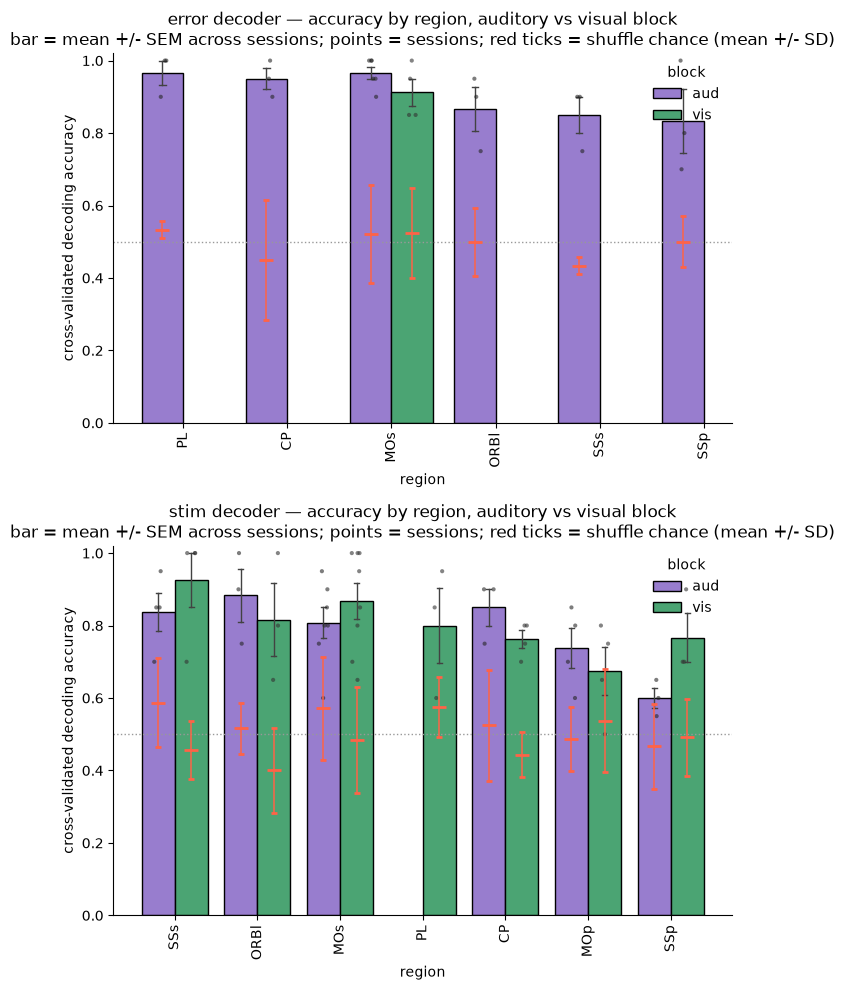

In [32]:
# Mean decoding accuracy per region, auditory vs visual block (mean +/- SEM
# across sessions, with individual session points). One row per decoder family.
BLOCK_PAL = {'aud': 'mediumpurple', 'vis': 'mediumseagreen'}
BLOCK_ORDER = ['aud', 'vis']

fig, axes = plt.subplots(2, 1, figsize=(max(7, 0.55 * plot_df.region.nunique()), 10))

for ax, family in zip(axes, ['error', 'stim']):
    d = plot_df[plot_df.family == family]
    order = (d.groupby('region')[acc_col].mean()
             .sort_values(ascending=False).index.tolist())

    sns.barplot(data=d, x='region', y=acc_col, hue='block', order=order,
                hue_order=BLOCK_ORDER, palette=BLOCK_PAL, edgecolor='black',
                errorbar='se', capsize=0.12, err_kws={'linewidth': 1.0}, ax=ax)
    sns.stripplot(data=d, x='region', y=acc_col, hue='block', order=order,
                  hue_order=BLOCK_ORDER, dodge=True, color='0.2', size=3,
                  jitter=0.12, alpha=0.6, legend=False, ax=ax)

    # per-region, per-block shuffle chance (mean +/- SD of the null), placed on
    # the dodged bar centres
    for xi, region in enumerate(order):
        for sign, blk in zip((-0.2, 0.2), BLOCK_ORDER):
            sub = d[(d.region == region) & (d.block == blk)]
            if len(sub):
                ax.errorbar(xi + sign, sub['chance'].mean(),
                            yerr=sub['chance_std'].mean(), fmt='_', color='tomato',
                            markersize=10, markeredgewidth=2, elinewidth=1.1,
                            capsize=2, zorder=5)

    ax.axhline(0.5, ls=':', color='0.6', linewidth=1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel('region')
    ax.set_ylabel('cross-validated decoding accuracy')
    ax.set_title(f'{family} decoder — accuracy by region, auditory vs visual block\n'
                 'bar = mean +/- SEM across sessions; points = sessions; '
                 'red ticks = shuffle chance (mean +/- SD)')
    ax.tick_params(axis='x', rotation=90)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], title='block', loc='upper right', frameon=False)
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


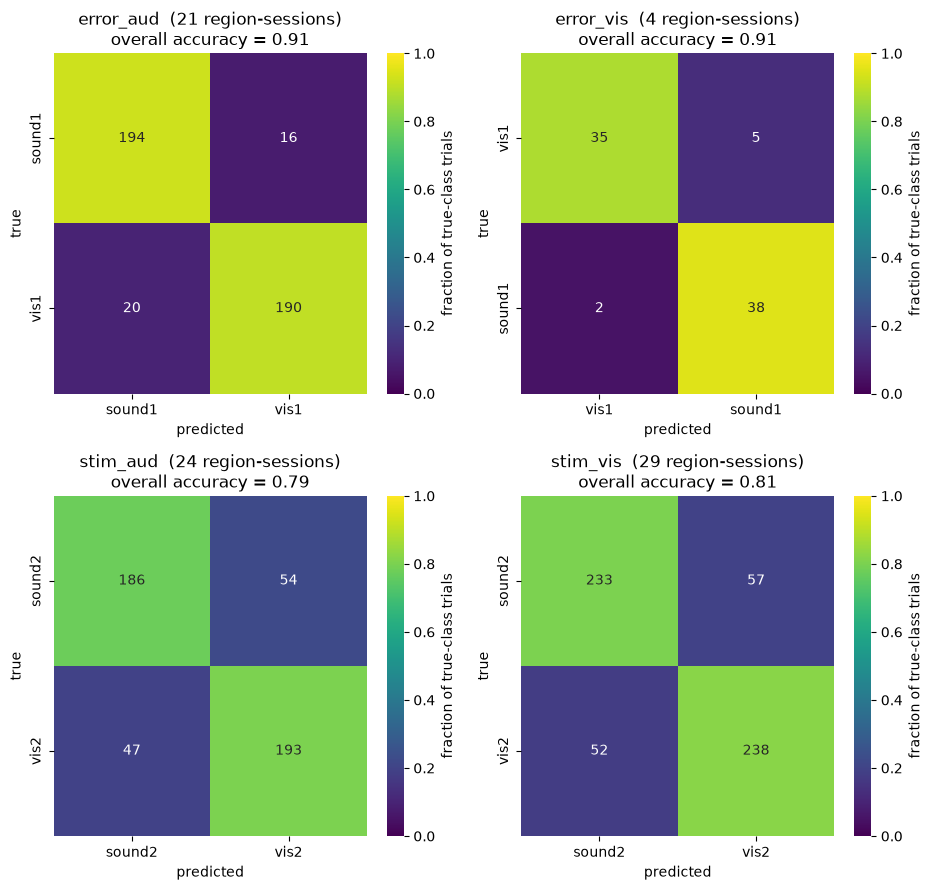

In [33]:
# Pooled confusion matrix for each of the four decoders (cross-validated
# predictions summed across all ok region-sessions, then row-normalised).
fig, axes = plt.subplots(2, 2, figsize=(9.5, 9))

for ax, name in zip(axes.ravel(), DECODERS):
    g = ok_all[ok_all.decoder == name]
    if not len(g):
        ax.set_visible(False)
        continue
    labels = g['confusion_labels'].iloc[0]
    conf_total = np.sum(np.stack(g['confusion_matrix'].values), axis=0)
    conf_frac = conf_total / conf_total.sum(axis=1, keepdims=True)
    sns.heatmap(conf_frac, annot=conf_total, fmt='d', cmap='viridis',
                vmin=0, vmax=1, xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'fraction of true-class trials'}, ax=ax)
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
    ax.set_title(f'{name}  ({len(g)} region-sessions)\n'
                 f'overall accuracy = {np.diag(conf_total).sum() / conf_total.sum():.2f}')

fig.tight_layout()
plt.show()


## Which neurons carry each decoder (feature importance)

For every decoder (all four: error / stim × aud / vis) each region-session is
fit `N_IMPORTANCE_REPEATS` times on independent stratified train/test splits.
In each repeat `r` we keep the weight vector `w_r`, score `accuracy_r` on the
held-out trials, and flag the top `IMPORTANCE_TOP_FRAC` of neurons by `|w_r|`
as "important".

Two per-neuron quantities come out of this:

* **`weight_stability`** — the fraction of repeats in which the neuron was
  flagged. This is the feature-importance ranking (`weight_abs_mean`, the mean
  `|w_r|` across repeats, is the continuous version).
* **`single_unit_stat`** — the circularity-safe firing-property estimate,
  computed **only on the held-out trials** of the repeats in which the neuron
  was both flagged and had test trials of both classes. For the **error**
  decoders it is `mean rate on hit trials − mean rate on false-alarm trials`;
  for the **stim** decoders it is `mean rate on sound2 − mean rate on vis2`.
  Selection (flagging) and measurement never use the same trials, so it is not
  inflated by selection bias.

The plots compare the auditory and visual block within each decoder family.

In [34]:
# Unpack the per-neuron importance arrays into one long table (one row per unit
# per region-session per decoder).
def unit_importance_table(ok_rows):
    out = []
    for _, r in ok_rows.iterrows():
        for j, uid in enumerate(r['unit_ids']):
            out.append(dict(
                decoder=r['decoder'],
                family=r['family'],
                block=r['block'],
                mouse_id=r['mouse_id'],
                region=r['region'],
                unit_id=int(uid),
                weight_stability=float(r['weight_stability'][j]),
                weight_abs_mean=float(r['weight_abs_mean'][j]),
                single_unit_stat=float(r['single_unit_stat'][j]),
                n_stat_reps=int(r['single_unit_stat_n_reps'][j]),
            ))
    return pd.DataFrame(out)

unit_importance = unit_importance_table(ok_all)

n_flag_frac = (ok_all['n_flagged_per_rep'].iloc[0]
               / len(ok_all['weight_stability'].iloc[0]))
for name, g in unit_importance.groupby('decoder'):
    n_rs = g.groupby(['mouse_id', 'region']).ngroups
    print(f"{name:<10}: {len(g)} units across {n_rs} region-sessions")
print(f"~{n_flag_frac:.0%} of neurons flagged per repeat (chance stability)")

unit_importance.sort_values('weight_stability', ascending=False).head(15)


error_aud : 1050 units across 21 region-sessions
error_vis : 200 units across 4 region-sessions
stim_aud  : 1200 units across 24 region-sessions
stim_vis  : 1450 units across 29 region-sessions
~10% of neurons flagged per repeat (chance stability)


,decoder,family,block,mouse_id,region,unit_id,weight_stability,weight_abs_mean,single_unit_stat,n_stat_reps
38,error_aud,error,aud,662892,ORBl,765,1.0,0.082437,-2.129630,3
3838,stim_vis,stim,vis,759434,MOs,2153,1.0,0.279067,2.314815,3
3841,stim_vis,stim,vis,759434,MOs,2211,1.0,0.216798,6.944444,3
747,error_aud,error,aud,742903,SSs,1173,1.0,0.093827,0.833333,3
730,error_aud,error,aud,742903,SSs,1012,1.0,0.099960,-5.740741,3
700,error_aud,error,aud,742903,SSs,756,1.0,0.242354,6.851852,3
683,error_aud,error,aud,742903,SSp,879,1.0,0.047134,-3.981481,3
663,error_aud,error,aud,742903,SSp,380,1.0,0.119615,13.148148,3
651,error_aud,error,aud,742903,SSp,91,1.0,0.071123,-13.518519,3
819,error_aud,error,aud,743199,MOs,1627,1.0,0.051490,0.740741,3


/tmp/ipykernel_535/2997281706.py:13: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=d, x='region', y='weight_stability', hue='block',
/tmp/ipykernel_535/2997281706.py:13: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=d, x='region', y='weight_stability', hue='block',


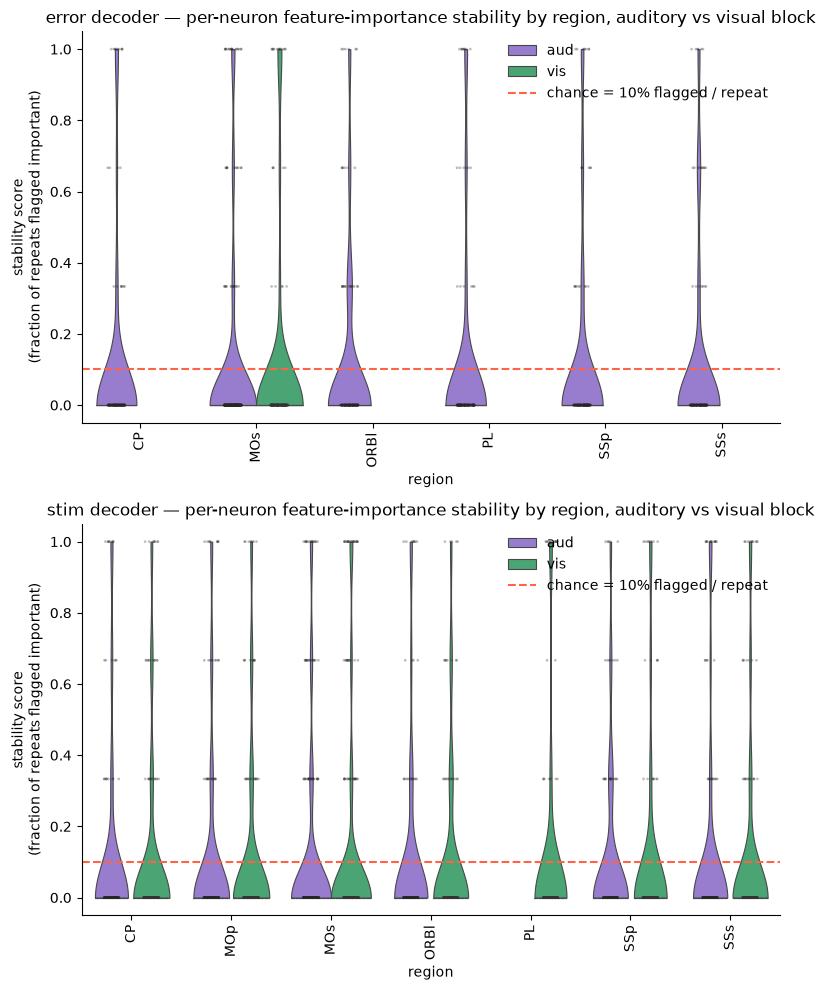

In [35]:
# Feature-importance ranking: per-neuron stability score by region, auditory
# vs visual block, one row per decoder family.
fig, axes = plt.subplots(2, 1, figsize=(max(8, 0.55 * unit_importance.region.nunique()), 10))

for ax, family in zip(axes, ['error', 'stim']):
    d = unit_importance[unit_importance.family == family]
    order = (d.groupby('region')['weight_stability'].mean()
             .sort_values(ascending=False).index.tolist())

    sns.violinplot(data=d, x='region', y='weight_stability', hue='block',
                   order=order, hue_order=BLOCK_ORDER, palette=BLOCK_PAL,
                   cut=0, inner='quartile', linewidth=0.8, ax=ax)
    sns.stripplot(data=d, x='region', y='weight_stability', hue='block',
                  order=order, hue_order=BLOCK_ORDER, dodge=True, color='0.2',
                  size=2, jitter=0.15, alpha=0.3, legend=False, ax=ax)
    ax.axhline(n_flag_frac, ls='--', color='tomato', linewidth=1.5,
               label=f'chance = {n_flag_frac:.0%} flagged / repeat')
    ax.set_xlabel('region')
    ax.set_ylabel('stability score\n(fraction of repeats flagged important)')
    ax.set_title(f'{family} decoder — per-neuron feature-importance stability '
                 'by region, auditory vs visual block')
    ax.tick_params(axis='x', rotation=90)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:3], labels[:3], frameon=False, loc='upper right')
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


207 units with >= 3 contributing repeats (of 3900 total)


/tmp/ipykernel_535/2400730874.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=stable, x='region', y='single_unit_stat', hue='block',
/tmp/ipykernel_535/2400730874.py:41: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:0.2'` for the same effect.

  sns.stripplot(data=stable, x='region', y='single_unit_stat', hue='block',


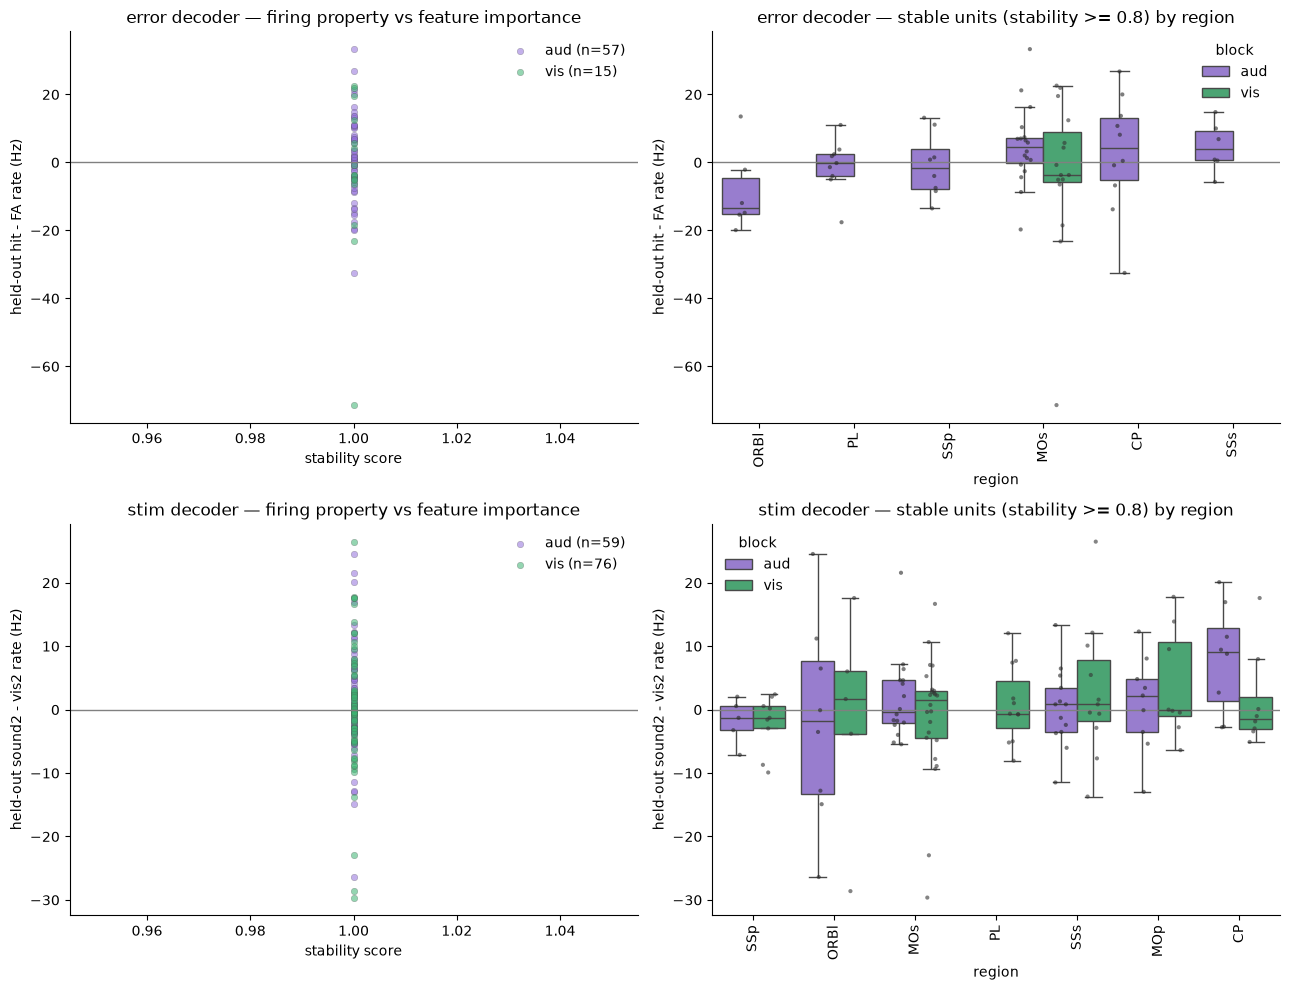

In [36]:
# Circularity-safe firing property of the important neurons, auditory vs visual
# block. single_unit_stat = held-out (hit - FA) rate for the error decoders,
# held-out (sound2 - vis2) rate for the stim decoders, averaged over the
# repeats in which the neuron was flagged.
MIN_STAT_REPS = 3
STAT_LABEL = {'error': 'held-out hit - FA rate (Hz)',
              'stim': 'held-out sound2 - vis2 rate (Hz)'}

su = unit_importance[unit_importance.n_stat_reps >= MIN_STAT_REPS].copy()
print(f"{len(su)} units with >= {MIN_STAT_REPS} contributing repeats "
      f"(of {len(unit_importance)} total)")

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for row, family in enumerate(['error', 'stim']):
    d = su[su.family == family]

    # left: firing statistic vs stability, coloured by block
    ax = axes[row, 0]
    for blk in BLOCK_ORDER:
        s = d[d.block == blk]
        ax.scatter(s['weight_stability'], s['single_unit_stat'], s=22, alpha=0.55,
                   color=BLOCK_PAL[blk], edgecolor='0.3', linewidth=0.3,
                   label=f'{blk} (n={len(s)})')
    ax.axhline(0, color='0.5', linewidth=1)
    ax.set_xlabel('stability score')
    ax.set_ylabel(STAT_LABEL[family])
    ax.set_title(f'{family} decoder — firing property vs feature importance')
    ax.legend(frameon=False)
    sns.despine(ax=ax)

    # right: distribution of the statistic per region (stable units only)
    ax = axes[row, 1]
    stable = d[d.weight_stability >= 0.8]
    reg_order = (stable.groupby('region')['single_unit_stat'].mean()
                 .sort_values().index.tolist())
    if len(stable):
        sns.boxplot(data=stable, x='region', y='single_unit_stat', hue='block',
                    order=reg_order, hue_order=BLOCK_ORDER, palette=BLOCK_PAL,
                    fliersize=0, ax=ax)
        sns.stripplot(data=stable, x='region', y='single_unit_stat', hue='block',
                      order=reg_order, hue_order=BLOCK_ORDER, dodge=True,
                      color='0.2', size=3, jitter=0.15, alpha=0.6, legend=False, ax=ax)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title='block', frameon=False)
    ax.axhline(0, color='0.5', linewidth=1)
    ax.set_xlabel('region')
    ax.set_ylabel(STAT_LABEL[family])
    ax.set_title(f'{family} decoder — stable units (stability >= 0.8) by region')
    ax.tick_params(axis='x', rotation=90)
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


## Error-exclusive neurons: error decoder vs stim decoder, within each block

Within a block the error and stim decoders are run on the same region-sessions
and the same 50-unit subsample, so each unit has two `weight_stability`
scores:

* **error decoder** — target hit vs distractor false alarm (stimulus identity
  *and* lick / error signal),
* **stim decoder** — sound2 vs vis2 on correct-reject trials (stimulus
  identity only, lick withheld).

A unit that is a stable feature of the error decoder but *not* of the stim
decoder carries the lick / error signal rather than stimulus identity. We flag
those as **error-exclusive**: `stability(error) >= HIGH` and
`stability(stim) <= LOW`. This is computed separately for the auditory and the
visual block, and then compared across the two blocks.

[aud] 800 units decoded by BOTH families (5 regions, 7 mice)  |  error-exclusive 24  stim-exclusive 26  shared-stable 9
[vis] 200 units decoded by BOTH families (1 regions, 4 mice)  |  error-exclusive 8  stim-exclusive 7  shared-stable 3


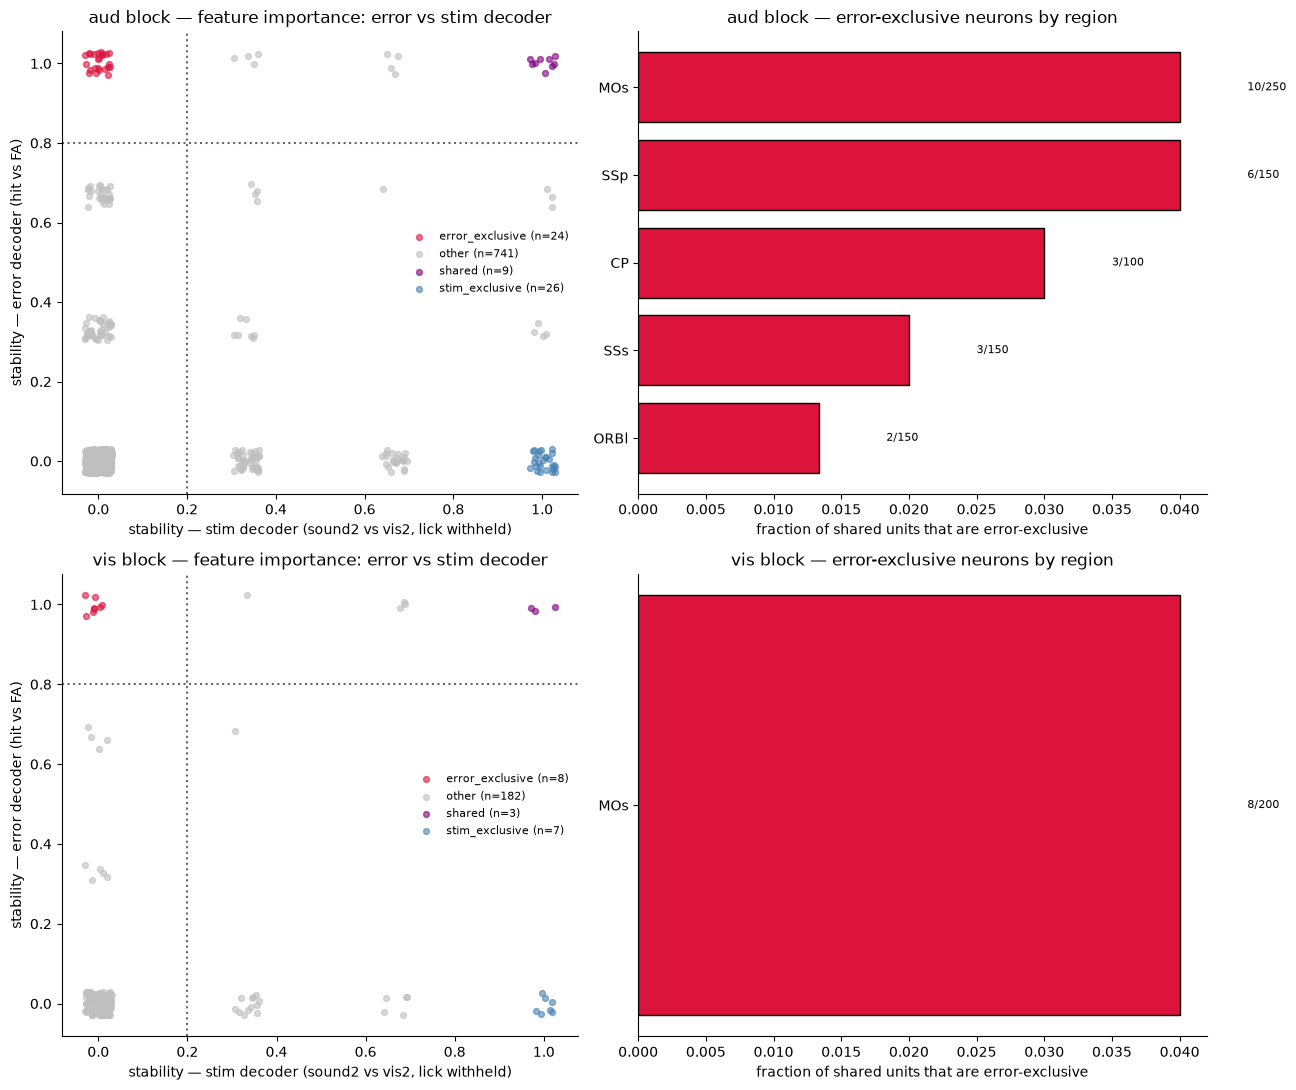

In [37]:
# Match units across the error and stim decoders on (mouse, region, unit_id),
# separately within each block.
HIGH = 0.8      # "stable feature" threshold
LOW = 0.2       # "not a feature" threshold

def compare_families(block):
    e = unit_importance[(unit_importance.family == 'error')
                        & (unit_importance.block == block)]
    s = unit_importance[(unit_importance.family == 'stim')
                        & (unit_importance.block == block)]
    c = e.merge(s, on=['mouse_id', 'region', 'unit_id'],
                suffixes=('_error', '_stim'))
    c['block'] = block
    c['error_exclusive'] = ((c.weight_stability_error >= HIGH)
                            & (c.weight_stability_stim <= LOW))
    c['stim_exclusive'] = ((c.weight_stability_stim >= HIGH)
                           & (c.weight_stability_error <= LOW))
    c['shared'] = ((c.weight_stability_error >= HIGH)
                   & (c.weight_stability_stim >= HIGH))
    c['group'] = np.select(
        [c.error_exclusive, c.stim_exclusive, c.shared],
        ['error_exclusive', 'stim_exclusive', 'shared'], default='other')
    return c

cmp = pd.concat([compare_families('aud'), compare_families('vis')],
                ignore_index=True)

for blk in BLOCK_ORDER:
    b = cmp[cmp.block == blk]
    print(f"[{blk}] {len(b)} units decoded by BOTH families "
          f"({b.region.nunique()} regions, {b.mouse_id.nunique()} mice)  |  "
          f"error-exclusive {int(b.error_exclusive.sum())}  "
          f"stim-exclusive {int(b.stim_exclusive.sum())}  "
          f"shared-stable {int(b.shared.sum())}")

palette = {'error_exclusive': 'crimson', 'stim_exclusive': 'steelblue',
           'shared': 'purple', 'other': '0.75'}
jit = lambda v: v + np.random.uniform(-0.03, 0.03, len(v))

fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                         gridspec_kw={'width_ratios': [1, 1.1]})

for row, blk in enumerate(BLOCK_ORDER):
    b = cmp[cmp.block == blk]

    # left: stability(stim) vs stability(error)
    ax = axes[row, 0]
    for g, sub in b.groupby('group'):
        ax.scatter(jit(sub.weight_stability_stim), jit(sub.weight_stability_error),
                   s=18, alpha=0.6, color=palette[g], label=f'{g} (n={len(sub)})')
    ax.axvline(LOW, ls=':', color='0.4')
    ax.axhline(HIGH, ls=':', color='0.4')
    ax.set_xlabel('stability — stim decoder (sound2 vs vis2, lick withheld)')
    ax.set_ylabel('stability — error decoder (hit vs FA)')
    ax.set_title(f'{blk} block — feature importance: error vs stim decoder')
    ax.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax)

    # right: error-exclusive fraction per region
    ax = axes[row, 1]
    by_region = (b.groupby('region')
                 .agg(n_both=('unit_id', 'size'),
                      n_error_excl=('error_exclusive', 'sum'))
                 .assign(frac=lambda d: d.n_error_excl / d.n_both)
                 .sort_values('frac', ascending=False))
    ax.barh(by_region.index, by_region.frac, color='crimson', edgecolor='black')
    for yi, (reg, r) in enumerate(by_region.iterrows()):
        ax.text(r.frac + 0.005, yi, f"{int(r.n_error_excl)}/{int(r.n_both)}",
                va='center', fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('fraction of shared units that are error-exclusive')
    ax.set_title(f'{blk} block — error-exclusive neurons by region')
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()


32 error-exclusive units (stability_error >= 0.8, stability_stim <= 0.2)

150 units decoded by all four decoders (1 regions, 3 mice)
error-exclusive in both blocks: 1  |  aud only: 6  |  vis only: 6


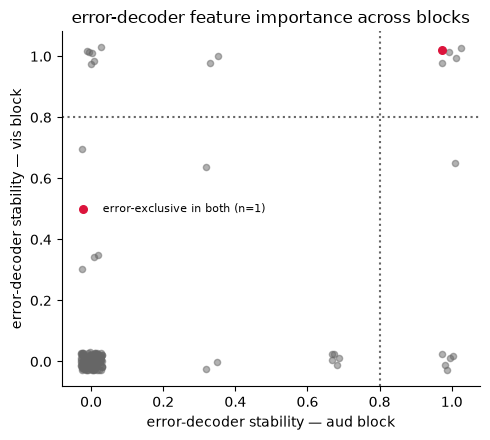

,block,mouse_id,region,unit_id,weight_stability_error,weight_stability_stim,single_unit_stat_error,n_stat_reps_error,single_unit_stat_stim,n_stat_reps_stim
0,aud,742903,CP,30,1.0,0.0,-0.833333,3,NaN,0
1,aud,742903,CP,326,1.0,0.0,0.462963,3,NaN,0
2,aud,759434,CP,26,1.0,0.0,-13.796296,3,NaN,0
3,aud,664851,MOs,1292,1.0,0.0,2.037037,3,NaN,0
4,aud,664851,MOs,1593,1.0,0.0,16.296296,3,NaN,0
5,aud,667252,MOs,916,1.0,0.0,6.481481,3,NaN,0
6,aud,667252,MOs,1037,1.0,0.0,7.037037,3,NaN,0
7,aud,714748,MOs,623,1.0,0.0,-8.703704,3,NaN,0
8,aud,715710,MOs,1707,1.0,0.0,3.240741,3,NaN,0
9,aud,715710,MOs,1768,1.0,0.0,-2.592593,3,NaN,0


In [39]:
# The error-exclusive neurons in each block, with their held-out firing stats.
#   single_unit_stat_error : held-out (hit - FA)      rate diff (Hz)
#   single_unit_stat_stim  : held-out (sound2 - vis2) rate diff (Hz)
error_exclusive = (
    cmp.loc[cmp.error_exclusive,
            ['block', 'mouse_id', 'region', 'unit_id',
             'weight_stability_error', 'weight_stability_stim',
             'single_unit_stat_error', 'n_stat_reps_error',
             'single_unit_stat_stim', 'n_stat_reps_stim']]
    .sort_values(['block', 'region', 'weight_stability_error'],
                 ascending=[True, True, False])
    .reset_index(drop=True))
print(f"{len(error_exclusive)} error-exclusive units "
      f"(stability_error >= {HIGH}, stability_stim <= {LOW})")

# --- across-block comparison: units tested in BOTH blocks -----------------
# (a unit is tested in both blocks only if its region-session met all four
#  decoders' criteria)
both = cmp[cmp.block == 'aud'].merge(
    cmp[cmp.block == 'vis'], on=['mouse_id', 'region', 'unit_id'],
    suffixes=('_aud', '_vis'))
print(f"\n{len(both)} units decoded by all four decoders "
      f"({both.region.nunique()} regions, {both.mouse_id.nunique()} mice)")
if len(both):
    n_both_excl = int((both.error_exclusive_aud & both.error_exclusive_vis).sum())
    n_aud_only = int((both.error_exclusive_aud & ~both.error_exclusive_vis).sum())
    n_vis_only = int((~both.error_exclusive_aud & both.error_exclusive_vis).sum())
    print(f"error-exclusive in both blocks: {n_both_excl}  |  "
          f"aud only: {n_aud_only}  |  vis only: {n_vis_only}")

    fig, ax = plt.subplots(figsize=(5, 4.5))
    ax.scatter(jit(both.weight_stability_error_aud.values),
               jit(both.weight_stability_error_vis.values),
               s=20, alpha=0.5, color='0.4')
    excl_both = both[both.error_exclusive_aud & both.error_exclusive_vis]
    ax.scatter(jit(excl_both.weight_stability_error_aud.values),
               jit(excl_both.weight_stability_error_vis.values),
               s=30, color='crimson', label=f'error-exclusive in both (n={len(excl_both)})')
    ax.axvline(HIGH, ls=':', color='0.4')
    ax.axhline(HIGH, ls=':', color='0.4')
    ax.set_xlabel('error-decoder stability — aud block')
    ax.set_ylabel('error-decoder stability — vis block')
    ax.set_title('error-decoder feature importance across blocks')
    ax.legend(frameon=False, fontsize=8)
    sns.despine(ax=ax)
    fig.tight_layout()
    plt.show()

error_exclusive


In [40]:
# =====================================================================
# SAVE RESULTS  --  persisted after the capsule is shut down
# ---------------------------------------------------------------------
# Code Ocean keeps everything written under /results (this capsule shows
# it as ./results, a symlink to /results). /scratch, the home directory
# and /code are NOT kept once the capsule stops, so results must go here.
#
# After the run finishes, download the folder printed below from the
# Results pane (or run a Reproducible Run) before discarding the capsule.
#
# Written into /results/decode_across_mice_regions/<timestamp>/ :
#   results_raw.pkl        full Pass 2 DataFrame `results` (one row per
#                          region-session) WITH every numpy array column
#                          (null_accuracy, coef_weights, weight_stability,
#                          weight_abs_mean, single_unit_stat, unit_ids,
#                          confusion_matrix, cv_accuracy_folds, ...).
#                          Reload with pandas.read_pickle(...).
#   pass2_results.csv      the same table, array columns dropped (flat view)
#   session_metadata.csv   `df`
#   pass1_scan.csv         `scan`  (per mouse x region criterion)
#   unit_importance.csv    `unit_importance`  (one row per unit/decoder)
#   family_comparison.csv  `cmp`  (error vs stim decoder, per unit)
#   error_exclusive.csv    `error_exclusive`
#   failed_sessions.csv    sessions the datacube mount would not serve
#   run_params.json        N_PERM, N_IMPORTANCE_REPEATS, thresholds, counts
#
# Figures are not saved here; add fig.savefig(run_dir / "name.png") if wanted.
# =====================================================================
import json, datetime, pathlib

_ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
run_dir = pathlib.Path("/results/decode_across_mice_regions") / _ts
run_dir.mkdir(parents=True, exist_ok=True)

def _dump_csv(name, obj):
    if obj is None:
        return
    frame = obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
    frame.to_csv(run_dir / name, index=False)
    print(f"  {name:<22} {len(frame):>5} rows")

# --- full raw Pass 2 output (the expensive result), arrays preserved ---
results.to_pickle(run_dir / "results_raw.pkl")
print(f"  {'results_raw.pkl':<22} {len(results):>5} region-sessions  (pickle)")

# --- flat CSV view: drop any column that holds ndarrays / lists ---
_arr_cols = [c for c in results.columns
             if results[c].map(lambda v: isinstance(v, (np.ndarray, list))).any()]
_dump_csv("pass2_results.csv", results.drop(columns=_arr_cols))

_dump_csv("session_metadata.csv", df)
_dump_csv("pass1_scan.csv", scan)
_dump_csv("unit_importance.csv", unit_importance)
_dump_csv("family_comparison.csv", cmp)
_dump_csv("error_exclusive.csv", error_exclusive)
_dump_csv("failed_sessions.csv", pd.DataFrame(failed_sessions))

with open(run_dir / "run_params.json", "w") as _fh:
    json.dump(dict(
        run_local_time=_ts,
        N_PERM=N_PERM,
        N_IMPORTANCE_REPEATS=N_IMPORTANCE_REPEATS,
        IMPORTANCE_TOP_FRAC=IMPORTANCE_TOP_FRAC,
        MIN_UNITS=MIN_UNITS,
        MIN_TRIALS_PER_CLASS=MIN_TRIALS_PER_CLASS,
        MIN_SESSIONS=MIN_SESSIONS,
        N_LOAD_RETRIES=N_LOAD_RETRIES,
        n_region_sessions=int(len(results)),
        n_ok=int((results.status == "ok").sum()),
        n_failed_sessions=int(len(failed_sessions)),
    ), _fh, indent=2)
print(f"  {'run_params.json':<22}")

print(f"\nsaved to: {run_dir}")
print("(under /results -> kept by Code Ocean after the capsule shuts down)")


  results_raw.pkl           78 region-sessions  (pickle)
  pass2_results.csv         78 rows
  session_metadata.csv      12 rows
  pass1_scan.csv           203 rows
  unit_importance.csv     3900 rows
  family_comparison.csv   1000 rows
  error_exclusive.csv       32 rows
  failed_sessions.csv        1 rows
  run_params.json       

saved to: /results/decode_across_mice_regions/20260902_053919
(under /results -> kept by Code Ocean after the capsule shuts down)
